In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
LOWER_LIMIT = 18
UPPER_LIMIT = 22

In [16]:
def thermal_plant(temperature, Q, dt=1):

    ambient_temperature = 20  # °C
    C = 10000  # Thermal capacitance, J/degC
    UA = 50  # Heat-loss coefficient, W/degC
    # dt = 1  # Time step, s

    dTdt = (Q - UA * (temperature - ambient_temperature)) / C
    new_temperature = temperature + dTdt * dt

    return new_temperature

In [17]:
# Rule-based agent
def my_agent_decision(temperature):

    Q = 0

    if temperature < LOWER_LIMIT:
        Q = 1000
    elif temperature > UPPER_LIMIT:
        Q = -1000
    else:
        Q = 0

    return Q

In [18]:
from ollama import chat

def ask_llama(prompt):

    response = chat(
        model="llama3.2:1b",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    return response.message.content


In [19]:
from dotenv import load_dotenv
from openai import OpenAI

# Load the API key and create the client
load_dotenv()
openai_client = OpenAI()

def ask_gpt(prompt):

    response = openai_client.responses.create(
        model="gpt-4o-mini",
        input=prompt
    )

    return response.output_text


In [20]:
def ai_decision(temperature, ask_model=ask_llama):

    prompt = f"""
    You are the controller for a thermal system.

    Goal:
    Keep the temperature between {LOWER_LIMIT} and {UPPER_LIMIT} °C.

    Current temperature:
    {temperature:.2f} °C

    Choose exactly one heat input:

    1000  = heating
    0     = no heating or cooling
    -1000 = cooling

    Your entire response must be exactly one of these values:

    1000
    0
    -1000

    Do not repeat the temperature.
    Do not include units or an explanation.
    """

    response = ask_model(prompt)
    Q = float(response.strip())

    if Q not in {-1000, 0, 1000}:
        raise ValueError(f"Invalid heat input: {Q}")

    return Q

In [21]:
# Initialize the environment

# Observation
temperature = 30 # °C

# State
state = {}
action = ""

# Memory
history = []

# Time
current_time = 0

# Delta time
dt = 10  # seconds


In [22]:
# Agentic Loop

for step in range(5):

    # Decision
    Q = ai_decision(temperature, ask_gpt)

    # Action
    new_temperature = thermal_plant(
        temperature,
        Q,
        dt=dt
    )

    # Evaluation
    if LOWER_LIMIT <= new_temperature <= UPPER_LIMIT:
        evaluation = "GOAL MET"
    else:
        evaluation = "GOAL NOT MET"

    # Update state
    state["time"] = current_time
    state["temperature"] = new_temperature
    state["action"] = Q
    state["evaluation"] = evaluation

    # Memory
    history.append(state.copy())

    # Update observation
    temperature = new_temperature

    # Advance time
    current_time = current_time + dt


In [23]:
print("Temperature:", temperature, "°C")
print("Action:", action)
print(state)

Temperature: 23.213428124999997 °C
Action: 
{'time': 40, 'temperature': 23.213428124999997, 'action': -1000.0, 'evaluation': 'GOAL NOT MET'}


In [24]:
# Convert into pandas DataFrames
df = pd.DataFrame(history)
df.to_csv("history.csv", index=False)

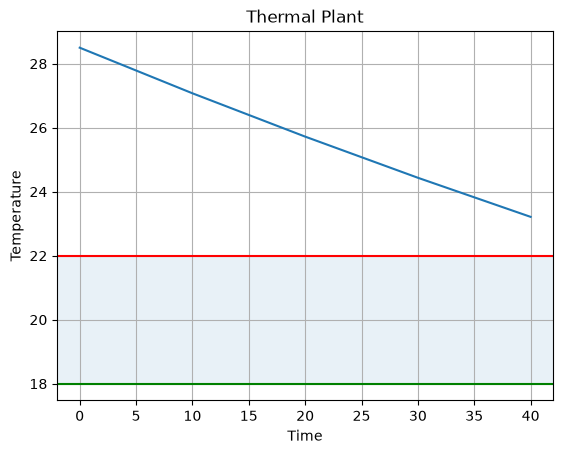

In [25]:
# Plot
plt.plot(
    df["time"],
    df["temperature"]
)

plt.grid()

plt.axhline(y=18, color="r", linestyle="-", c="g")
plt.axhline(y=22, color="r", linestyle="-", c='r')
plt. axhspan(18, 22, alpha=0.1)

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Thermal Plant")

plt.show()